In [1]:
!pip install torch numpy matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import os, copy

ALPHA       = 1.0
T_MAX       = 0.01
N_DOMAIN    = 3000
N_BOUNDARY  = 800
N_INITIAL   = 2000
W_PDE = 1; W_BC = 10; W_IC = 30
SIGMA_BANDS = [1, 3, 5]
M_FREQ      = 32
MLP_HIDDEN  = [256] * 6
MODEL_PATH  = '../../results/pinn_parametric.pt'
OUT_DIR     = '../../results/ood/fixes'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
print(f'Device: {DEVICE}')

Device: cpu


In [3]:
def T_exact(x, y, t, Lx, Ly, alpha=ALPHA):
    lam1 = np.pi**2 * alpha * (1/Lx**2 + 1/Ly**2)
    lam2 = 25 * lam1
    low  = np.sin(np.pi*x/Lx)*np.sin(np.pi*y/Ly)*np.exp(-lam1*t)
    high = 0.3*np.sin(5*np.pi*x/Lx)*np.sin(5*np.pi*y/Ly)*np.exp(-lam2*t)
    return low + high

In [4]:
class ParametricFourierNet(nn.Module):
    def __init__(self, sigma_bands, m_freq, mlp_hidden, t_max):
        super().__init__()
        self.sigma_bands = sigma_bands; self.t_max = t_max
        n_fourier = len(sigma_bands)*2*m_freq
        for i, sigma in enumerate(sigma_bands):
            B = torch.randn(3, m_freq)*sigma
            self.register_parameter(f'B_{i}', nn.Parameter(B, requires_grad=False))
        sizes = [n_fourier+2]+mlp_hidden+[1]
        layers = []
        for in_sz, out_sz in zip(sizes[:-2], sizes[1:-1]):
            layers += [nn.Linear(in_sz, out_sz), nn.Tanh()]
        layers.append(nn.Linear(sizes[-2], sizes[-1]))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        lx=x[:,3:4]; ly=x[:,4:5]
        xi_n=2.0*x[:,0:1]/lx-1.0; eta_n=2.0*x[:,1:2]/ly-1.0
        t_n=2.0*x[:,2:3]/self.t_max-1.0
        lx_n=(lx-1.25)/0.75; ly_n=(ly-1.25)/0.75
        coords=torch.cat([xi_n,eta_n,t_n],dim=1)
        features=[]
        for i in range(len(self.sigma_bands)):
            B=getattr(self,f'B_{i}'); proj=coords@B
            features+=[torch.sin(proj),torch.cos(proj)]
        return self.mlp(torch.cat(features+[lx_n,ly_n],dim=-1))

In [5]:
# Samplers and losses — same as training notebook
def sample_interior(Lx, Ly, n):
    x=torch.rand(n,1)*Lx; y=torch.rand(n,1)*Ly; t=torch.rand(n,1)*T_MAX
    pts=torch.cat([x,y,t,torch.full((n,1),Lx),torch.full((n,1),Ly)],dim=1).to(DEVICE)
    pts.requires_grad_(True); return pts

def sample_boundary(Lx, Ly, n):
    q=n//4; edges=[]
    for xv in [0.0,Lx]:
        y=torch.rand(q,1)*Ly; t=torch.rand(q,1)*T_MAX
        edges.append(torch.cat([torch.full((q,1),xv),y,t,torch.full((q,1),Lx),torch.full((q,1),Ly)],dim=1))
    for yv in [0.0,Ly]:
        x=torch.rand(q,1)*Lx; t=torch.rand(q,1)*T_MAX
        edges.append(torch.cat([x,torch.full((q,1),yv),t,torch.full((q,1),Lx),torch.full((q,1),Ly)],dim=1))
    return torch.cat(edges,dim=0).to(DEVICE)

def sample_ic(Lx, Ly, n):
    x=torch.rand(n,1)*Lx; y=torch.rand(n,1)*Ly; t=torch.zeros(n,1)
    return torch.cat([x,y,t,torch.full((n,1),Lx),torch.full((n,1),Ly)],dim=1).to(DEVICE)

def ic_target(pts):
    x,y,lx,ly=pts[:,0:1],pts[:,1:2],pts[:,3:4],pts[:,4:5]
    return torch.sin(np.pi*x/lx)*torch.sin(np.pi*y/ly)+0.3*torch.sin(5*np.pi*x/lx)*torch.sin(5*np.pi*y/ly)

def pde_residual(mdl, pts):
    T=mdl(pts); g=torch.autograd.grad(T.sum(),pts,create_graph=True)[0]
    Tx,Ty,Tt=g[:,0:1],g[:,1:2],g[:,2:3]
    Txx=torch.autograd.grad(Tx.sum(),pts,create_graph=True)[0][:,0:1]
    Tyy=torch.autograd.grad(Ty.sum(),pts,create_graph=True)[0][:,1:2]
    return Tt-ALPHA*(Txx+Tyy)

def eval_l2(mdl, Lx, Ly, t_val, alpha_true=ALPHA, grid_n=80):
    x_lin=np.linspace(0,Lx,grid_n); y_lin=np.linspace(0,Ly,grid_n)
    X,Y=np.meshgrid(x_lin,y_lin)
    pts=torch.tensor(np.column_stack([X.ravel(),Y.ravel(),
        np.full(X.size,t_val),np.full(X.size,Lx),np.full(X.size,Ly)]),
        dtype=torch.float32,device=DEVICE)
    with torch.no_grad():
        T_pred=mdl(pts).cpu().numpy().reshape(grid_n,grid_n)
    T_true=T_exact(X,Y,t_val,Lx,Ly,alpha=alpha_true)
    denom=np.linalg.norm(T_true)
    return np.linalg.norm(T_pred-T_true)/denom if denom>1e-12 else float('nan'), T_pred, T_true

print('Helpers ready.')

Helpers ready.


In [6]:
# Load pretrained model
model = ParametricFourierNet(SIGMA_BANDS, M_FREQ, MLP_HIDDEN, T_MAX).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print(f'Model loaded from {MODEL_PATH}')

Model loaded from ../../results/pinn_parametric.pt


## Fix 1 — Transfer Learning for Specific OOD Geometries

Instead of fine-tuning across a continuous OOD range, we train one **specialized model**
per target geometry — exactly the transfer learning approach: pretrained weights as
initialization, fine-tuned only for the new target.

- **Below bound**: `Lx=0.2, Ly=1.0`  (lx_n = −1.40, just outside training range)
- **Above bound**: `Lx=2.5, Ly=1.0`  (lx_n = +1.67, just outside training range)

Each specialized model is only ever queried on its target geometry.
The original model handles everything in `[0.5, 2.0]`.

In [7]:
# Target geometries
BELOW = (0.2, 1.0)   # below training bound
ABOVE = (2.5, 1.0)   # above training bound

# Baseline errors before any fine-tuning
for name, (Lx, Ly) in [('Below bound  0.2x1.0', BELOW), ('Above bound  2.5x1.0', ABOVE)]:
    l2, _, _ = eval_l2(model, Lx, Ly, 0.001)
    lx_n = (Lx - 1.25) / 0.75
    print(f'BEFORE  {name}  lx_n={lx_n:.2f}  L2={l2:.2e}')

BEFORE  Below bound  0.2x1.0  lx_n=-1.40  L2=1.40e-01
BEFORE  Above bound  2.5x1.0  lx_n=1.67  L2=2.77e-02


In [8]:
# Specialized model for BELOW bound (Lx=0.2, Ly=1.0)
# Fine-tune ONLY on this specific geometry — small LR, cosine annealing
Lx_b, Ly_b = BELOW
model_below = copy.deepcopy(model)
model_below.train()
opt_b   = torch.optim.Adam(model_below.parameters(), lr=1e-4)
sched_b = torch.optim.lr_scheduler.CosineAnnealingLR(opt_b, T_max=10000, eta_min=1e-6)

for step in range(10000):
    p_int = sample_interior(Lx_b, Ly_b, N_DOMAIN)
    p_bc  = sample_boundary(Lx_b, Ly_b, N_BOUNDARY)
    p_ic  = sample_ic(Lx_b,      Ly_b, N_INITIAL)
    opt_b.zero_grad()
    l_pde = (pde_residual(model_below, p_int)**2).mean()
    l_bc  = (model_below(p_bc)**2).mean()
    l_ic  = ((model_below(p_ic) - ic_target(p_ic))**2).mean()
    loss  = W_PDE*l_pde + W_BC*l_bc + W_IC*l_ic
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_below.parameters(), 1.0)
    opt_b.step(); sched_b.step()
    if step % 2000 == 0:
        print(f'  [below] step {step:5d} | loss={loss.item():.3e} | lr={sched_b.get_last_lr()[0]:.2e}')

model_below.eval()
print('Below-bound model done.')

  [below] step     0 | loss=9.289e+03 | lr=1.00e-04


  [below] step  2000 | loss=1.165e+00 | lr=9.05e-05


  [below] step  4000 | loss=9.635e-01 | lr=6.58e-05


  [below] step  6000 | loss=7.915e-01 | lr=3.52e-05


  [below] step  8000 | loss=7.627e-01 | lr=1.04e-05


Below-bound model done.


In [9]:
# Specialized model for ABOVE bound (Lx=2.5, Ly=1.0)
Lx_a, Ly_a = ABOVE
model_above = copy.deepcopy(model)
model_above.train()
opt_a   = torch.optim.Adam(model_above.parameters(), lr=1e-4)
sched_a = torch.optim.lr_scheduler.CosineAnnealingLR(opt_a, T_max=10000, eta_min=1e-6)

for step in range(10000):
    p_int = sample_interior(Lx_a, Ly_a, N_DOMAIN)
    p_bc  = sample_boundary(Lx_a, Ly_a, N_BOUNDARY)
    p_ic  = sample_ic(Lx_a,      Ly_a, N_INITIAL)
    opt_a.zero_grad()
    l_pde = (pde_residual(model_above, p_int)**2).mean()
    l_bc  = (model_above(p_bc)**2).mean()
    l_ic  = ((model_above(p_ic) - ic_target(p_ic))**2).mean()
    loss  = W_PDE*l_pde + W_BC*l_bc + W_IC*l_ic
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_above.parameters(), 1.0)
    opt_a.step(); sched_a.step()
    if step % 2000 == 0:
        print(f'  [above] step {step:5d} | loss={loss.item():.3e} | lr={sched_a.get_last_lr()[0]:.2e}')

model_above.eval()
print('Above-bound model done.')

  [above] step     0 | loss=5.316e+00 | lr=1.00e-04


  [above] step  2000 | loss=2.388e-02 | lr=9.05e-05


  [above] step  4000 | loss=1.490e-02 | lr=6.58e-05


  [above] step  6000 | loss=9.808e-03 | lr=3.52e-05


  [above] step  8000 | loss=5.965e-03 | lr=1.04e-05


Above-bound model done.


Below  0.2x1.0  before=1.40e-01  after=7.39e-02  improvement=1.9x
Above  2.5x1.0  before=2.77e-02  after=5.68e-03  improvement=4.9x


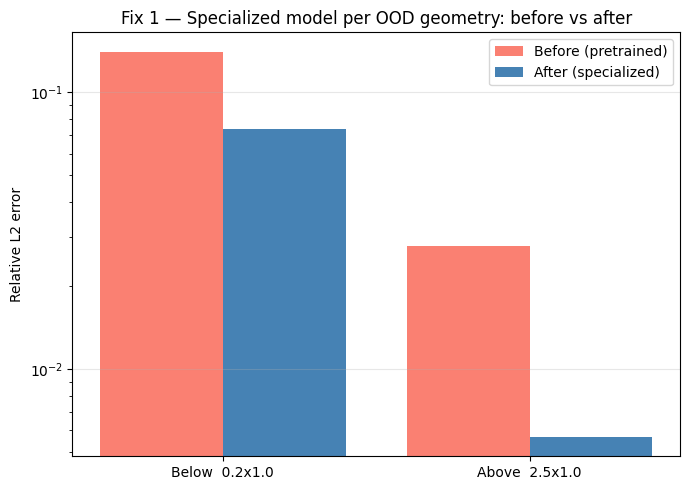

Saved fix1_transfer_learning.png


In [10]:
# Compare before vs after for both target geometries
results = []
for name, (Lx, Ly), mdl in [
    ('Below  0.2x1.0', BELOW, model_below),
    ('Above  2.5x1.0', ABOVE, model_above),
]:
    l2_before, _,      _      = eval_l2(model, Lx, Ly, 0.001)
    l2_after,  T_pred, T_true = eval_l2(mdl,   Lx, Ly, 0.001)
    results.append((name, Lx, Ly, l2_before, l2_after, T_pred, T_true))
    print(f'{name}  before={l2_before:.2e}  after={l2_after:.2e}  '
          f'improvement={l2_before/l2_after:.1f}x')

# Bar chart
labels  = [r[0] for r in results]
befores = [r[3] for r in results]
afters  = [r[4] for r in results]
x = [0, 1]
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar([v-0.2 for v in x], befores, 0.4, label='Before (pretrained)', color='salmon')
ax.bar([v+0.2 for v in x], afters,  0.4, label='After (specialized)',  color='steelblue')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Relative L2 error'); ax.set_yscale('log')
ax.set_title('Fix 1 — Specialized model per OOD geometry: before vs after')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fix1_transfer_learning.png', dpi=150)
plt.show()
print('Saved fix1_transfer_learning.png')

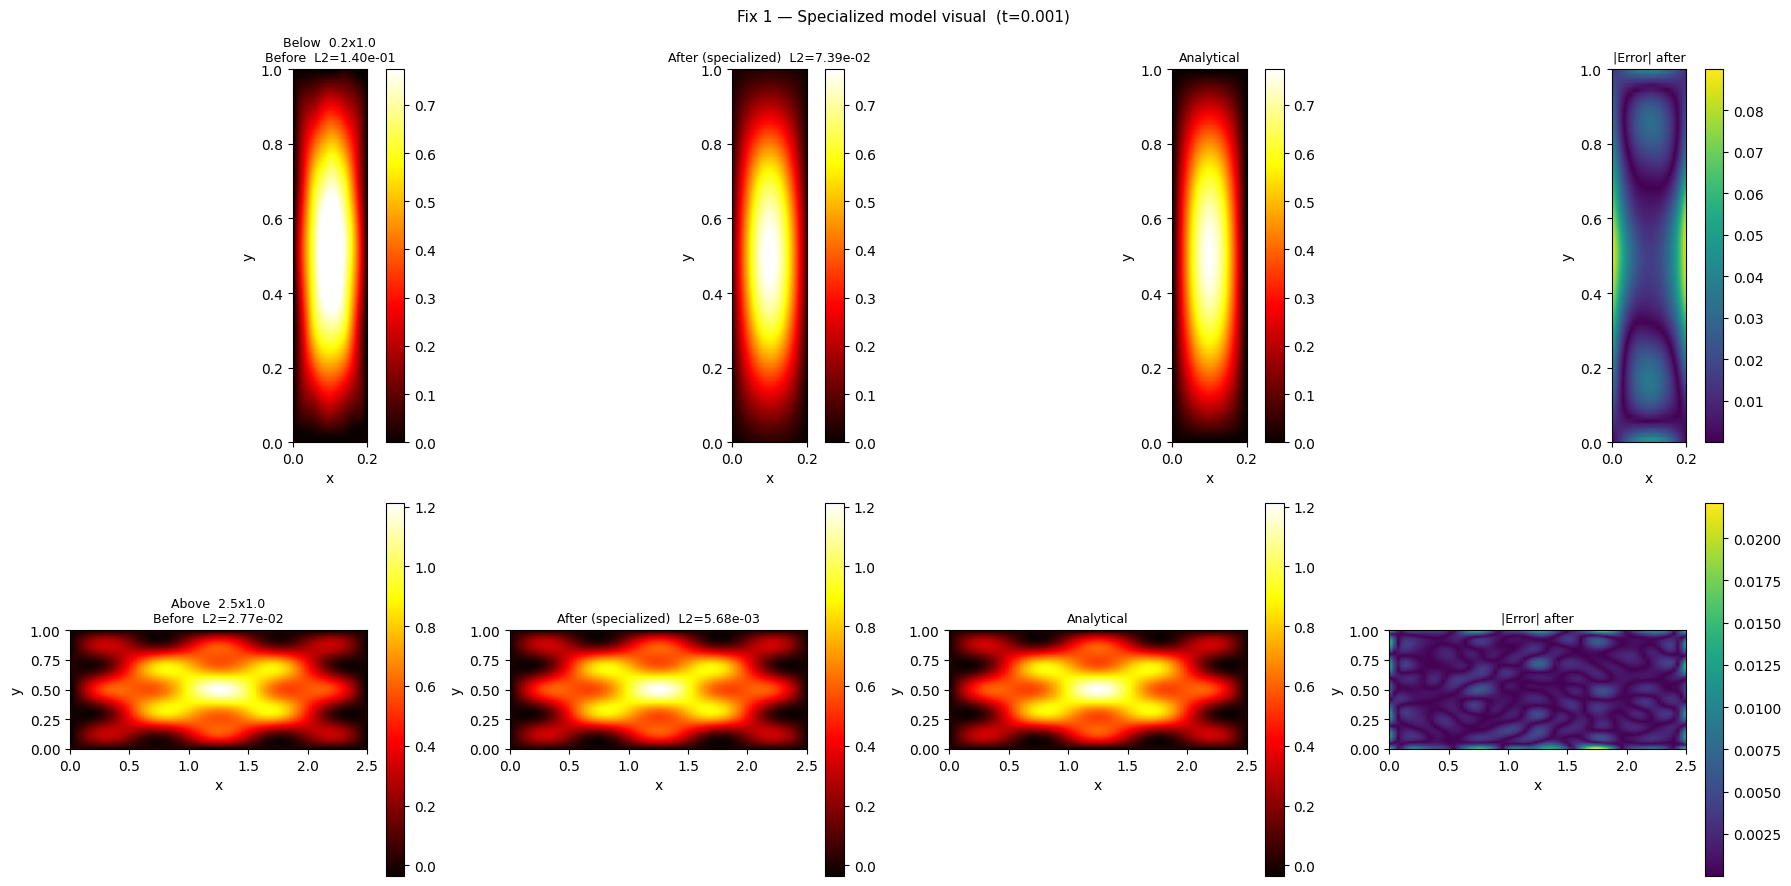

Saved fix1_transfer_visual.png


In [11]:
# Visual: PINN before | PINN after | Analytical | |Error| after
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for row, (name, Lx, Ly, l2_b, l2_a, T_after, T_true) in enumerate(results):
    l2_before, T_before, _ = eval_l2(model, Lx, Ly, 0.001)
    vmin=T_true.min(); vmax=T_true.max()
    kw=dict(origin='lower', extent=[0,Lx,0,Ly], cmap='hot', vmin=vmin, vmax=vmax)
    im=axes[row,0].imshow(T_before,**kw)
    axes[row,0].set_title(f'{name}\nBefore  L2={l2_before:.2e}', fontsize=9)
    plt.colorbar(im, ax=axes[row,0])
    im=axes[row,1].imshow(T_after,**kw)
    axes[row,1].set_title(f'After (specialized)  L2={l2_a:.2e}', fontsize=9)
    plt.colorbar(im, ax=axes[row,1])
    im=axes[row,2].imshow(T_true,**kw)
    axes[row,2].set_title('Analytical', fontsize=9)
    plt.colorbar(im, ax=axes[row,2])
    im=axes[row,3].imshow(np.abs(T_after-T_true), origin='lower',
                          extent=[0,Lx,0,Ly], cmap='viridis')
    axes[row,3].set_title('|Error| after', fontsize=9)
    plt.colorbar(im, ax=axes[row,3])
    for ax in axes[row]: ax.set_xlabel('x'); ax.set_ylabel('y')
fig.suptitle('Fix 1 — Specialized model visual  (t=0.001)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fix1_transfer_visual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fix1_transfer_visual.png')

## Fix 2 — Moving Time Window for Temporal Extrapolation
The original model (window 1) covers `t ∈ [0, T_MAX]`.
We train a second model (window 2) on `t ∈ [T_MAX, 2×T_MAX]`.

**Key idea:** the IC for window 2 at `t = T_MAX` is the output of window 1 at `t = T_MAX`.
To keep the same model architecture, we shift time: window 2 receives `t' = t − T_MAX ∈ [0, T_MAX]`
so the normalization `t_n = 2t'/T_MAX − 1` stays in `[−1, 1]`.

In [12]:
# Train window 2: t in [T_MAX, 2*T_MAX]
# Time is shifted by T_MAX before passing to the model so normalization stays in [-1,1]

model2 = ParametricFourierNet(SIGMA_BANDS, M_FREQ, MLP_HIDDEN, T_MAX).to(DEVICE)
opt2   = torch.optim.Adam(model2.parameters(), lr=1e-3)
sched2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=15000, eta_min=1e-5)

LX_RANGE = [0.5, 2.0]

def sample_interior_w2(Lx, Ly, n):
    x = torch.rand(n,1)*Lx; y = torch.rand(n,1)*Ly
    t_shifted = torch.rand(n,1)*T_MAX          # t' = t - T_MAX, so t' in [0, T_MAX]
    pts = torch.cat([x,y,t_shifted,torch.full((n,1),Lx),torch.full((n,1),Ly)],dim=1).to(DEVICE)
    pts.requires_grad_(True); return pts

def sample_boundary_w2(Lx, Ly, n):
    q=n//4; edges=[]
    for xv in [0.0,Lx]:
        y=torch.rand(q,1)*Ly; t=torch.rand(q,1)*T_MAX   # shifted time
        edges.append(torch.cat([torch.full((q,1),xv),y,t,torch.full((q,1),Lx),torch.full((q,1),Ly)],dim=1))
    for yv in [0.0,Ly]:
        x=torch.rand(q,1)*Lx; t=torch.rand(q,1)*T_MAX
        edges.append(torch.cat([x,torch.full((q,1),yv),t,torch.full((q,1),Lx),torch.full((q,1),Ly)],dim=1))
    return torch.cat(edges,dim=0).to(DEVICE)

def sample_ic_w2(Lx, Ly, n):
    # IC at t'=0 (i.e. t=T_MAX) — query model1 for target values
    x=torch.rand(n,1)*Lx; y=torch.rand(n,1)*Ly; t=torch.zeros(n,1)
    return torch.cat([x,y,t,torch.full((n,1),Lx),torch.full((n,1),Ly)],dim=1).to(DEVICE)

def ic_target_w2(pts_shifted):
    # Target is model1's prediction at t=T_MAX (unshifted)
    pts_m1 = pts_shifted.detach().clone()
    pts_m1[:,2] = T_MAX     # set actual t=T_MAX for model1
    with torch.no_grad():
        return model(pts_m1)   # model = window 1

print('Training window 2 model (15000 steps)...')
for step in range(15000):
    Lx = LX_RANGE[0] + torch.rand(1).item()*(LX_RANGE[1]-LX_RANGE[0])
    Ly = LX_RANGE[0] + torch.rand(1).item()*(LX_RANGE[1]-LX_RANGE[0])
    p_int = sample_interior_w2(Lx, Ly, N_DOMAIN)
    p_bc  = sample_boundary_w2(Lx, Ly, N_BOUNDARY)
    p_ic  = sample_ic_w2(Lx,       Ly, N_INITIAL)
    opt2.zero_grad()
    l_pde = (pde_residual(model2, p_int)**2).mean()
    l_bc  = (model2(p_bc)**2).mean()
    l_ic  = ((model2(p_ic) - ic_target_w2(p_ic))**2).mean()
    loss  = W_PDE*l_pde + W_BC*l_bc + W_IC*50*l_ic   # heavier IC weight for continuity
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model2.parameters(), 1.0)
    opt2.step(); sched2.step()
    if step % 3000 == 0:
        print(f'  step {step:5d} | loss={loss.item():.3e} pde={l_pde.item():.3e} ic={l_ic.item():.3e}')

model2.eval()
print('Window 2 training done.')

Training window 2 model (15000 steps)...
  step     0 | loss=3.546e+02 pde=8.462e+01 ic=1.800e-01


  step  3000 | loss=3.083e+00 pde=2.219e+00 ic=5.648e-04


  step  6000 | loss=4.677e+00 pde=2.431e+00 ic=1.466e-03


  step  9000 | loss=6.509e-01 pde=2.198e-01 ic=2.746e-04


  step 12000 | loss=1.448e-01 pde=6.958e-02 ic=4.396e-05


Window 2 training done.


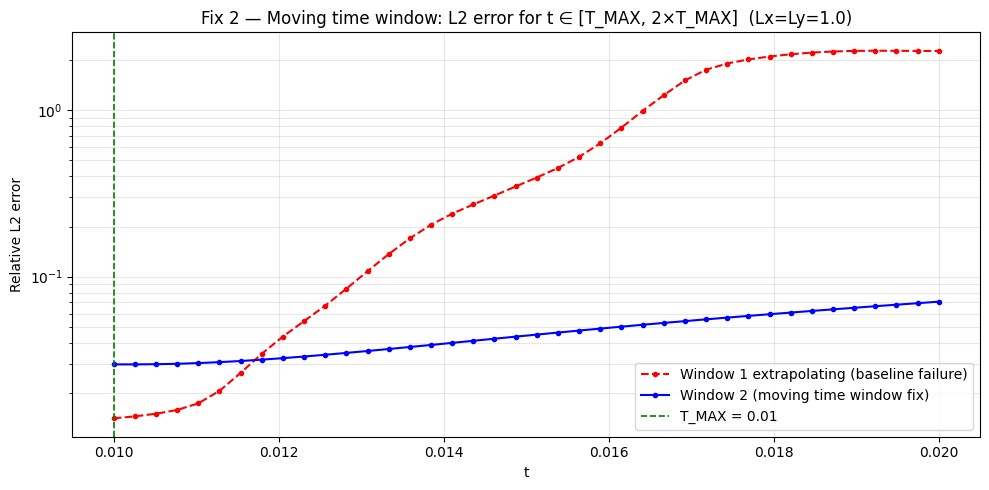

Saved fix2_time_window_sweep.png


In [13]:
# Evaluate: compare model1 extrapolating vs model2 (moving window) for t > T_MAX
# model2 receives t' = t - T_MAX, so we shift time before querying

def eval_l2_w2(Lx, Ly, t_val, grid_n=80):
    """Evaluate window 2 model for t > T_MAX.  Shifts time internally."""
    x_lin=np.linspace(0,Lx,grid_n); y_lin=np.linspace(0,Ly,grid_n)
    X,Y=np.meshgrid(x_lin,y_lin)
    pts=torch.tensor(np.column_stack([X.ravel(),Y.ravel(),
        np.full(X.size, t_val - T_MAX),   # shift: t' = t - T_MAX
        np.full(X.size,Lx),np.full(X.size,Ly)]),
        dtype=torch.float32,device=DEVICE)
    with torch.no_grad():
        T_pred=model2(pts).cpu().numpy().reshape(grid_n,grid_n)
    T_true=T_exact(X,Y,t_val,Lx,Ly)
    denom=np.linalg.norm(T_true)
    return np.linalg.norm(T_pred-T_true)/denom if denom>1e-12 else float('nan'), T_pred, T_true

# Sweep t from T_MAX to 2*T_MAX
t_ext = np.linspace(T_MAX, 2*T_MAX, 40)
Lx_t = Ly_t = 1.0
errs_w1 = [eval_l2(model,  Lx_t, Ly_t, t)[0] for t in t_ext]   # model1 extrapolating
errs_w2 = [eval_l2_w2(Lx_t, Ly_t, t)[0]      for t in t_ext]   # model2 (moving window)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(t_ext, errs_w1, 'r--o', ms=3, lw=1.5, label='Window 1 extrapolating (baseline failure)')
ax.semilogy(t_ext, errs_w2, 'b-o',  ms=3, lw=1.5, label='Window 2 (moving time window fix)')
ax.axvline(T_MAX, color='green', ls='--', lw=1.2, label=f'T_MAX = {T_MAX}')
ax.set_xlabel('t'); ax.set_ylabel('Relative L2 error')
ax.set_title('Fix 2 — Moving time window: L2 error for t ∈ [T_MAX, 2×T_MAX]  (Lx=Ly=1.0)')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fix2_time_window_sweep.png', dpi=150); plt.show()
print('Saved fix2_time_window_sweep.png')

      t |     W1 L2 |     W2 L2
 0.0100 |  1.41e-02 |  2.97e-02
 0.0150 |  3.70e-01 |  4.42e-02
 0.0200 |  2.27e+00 |  7.07e-02


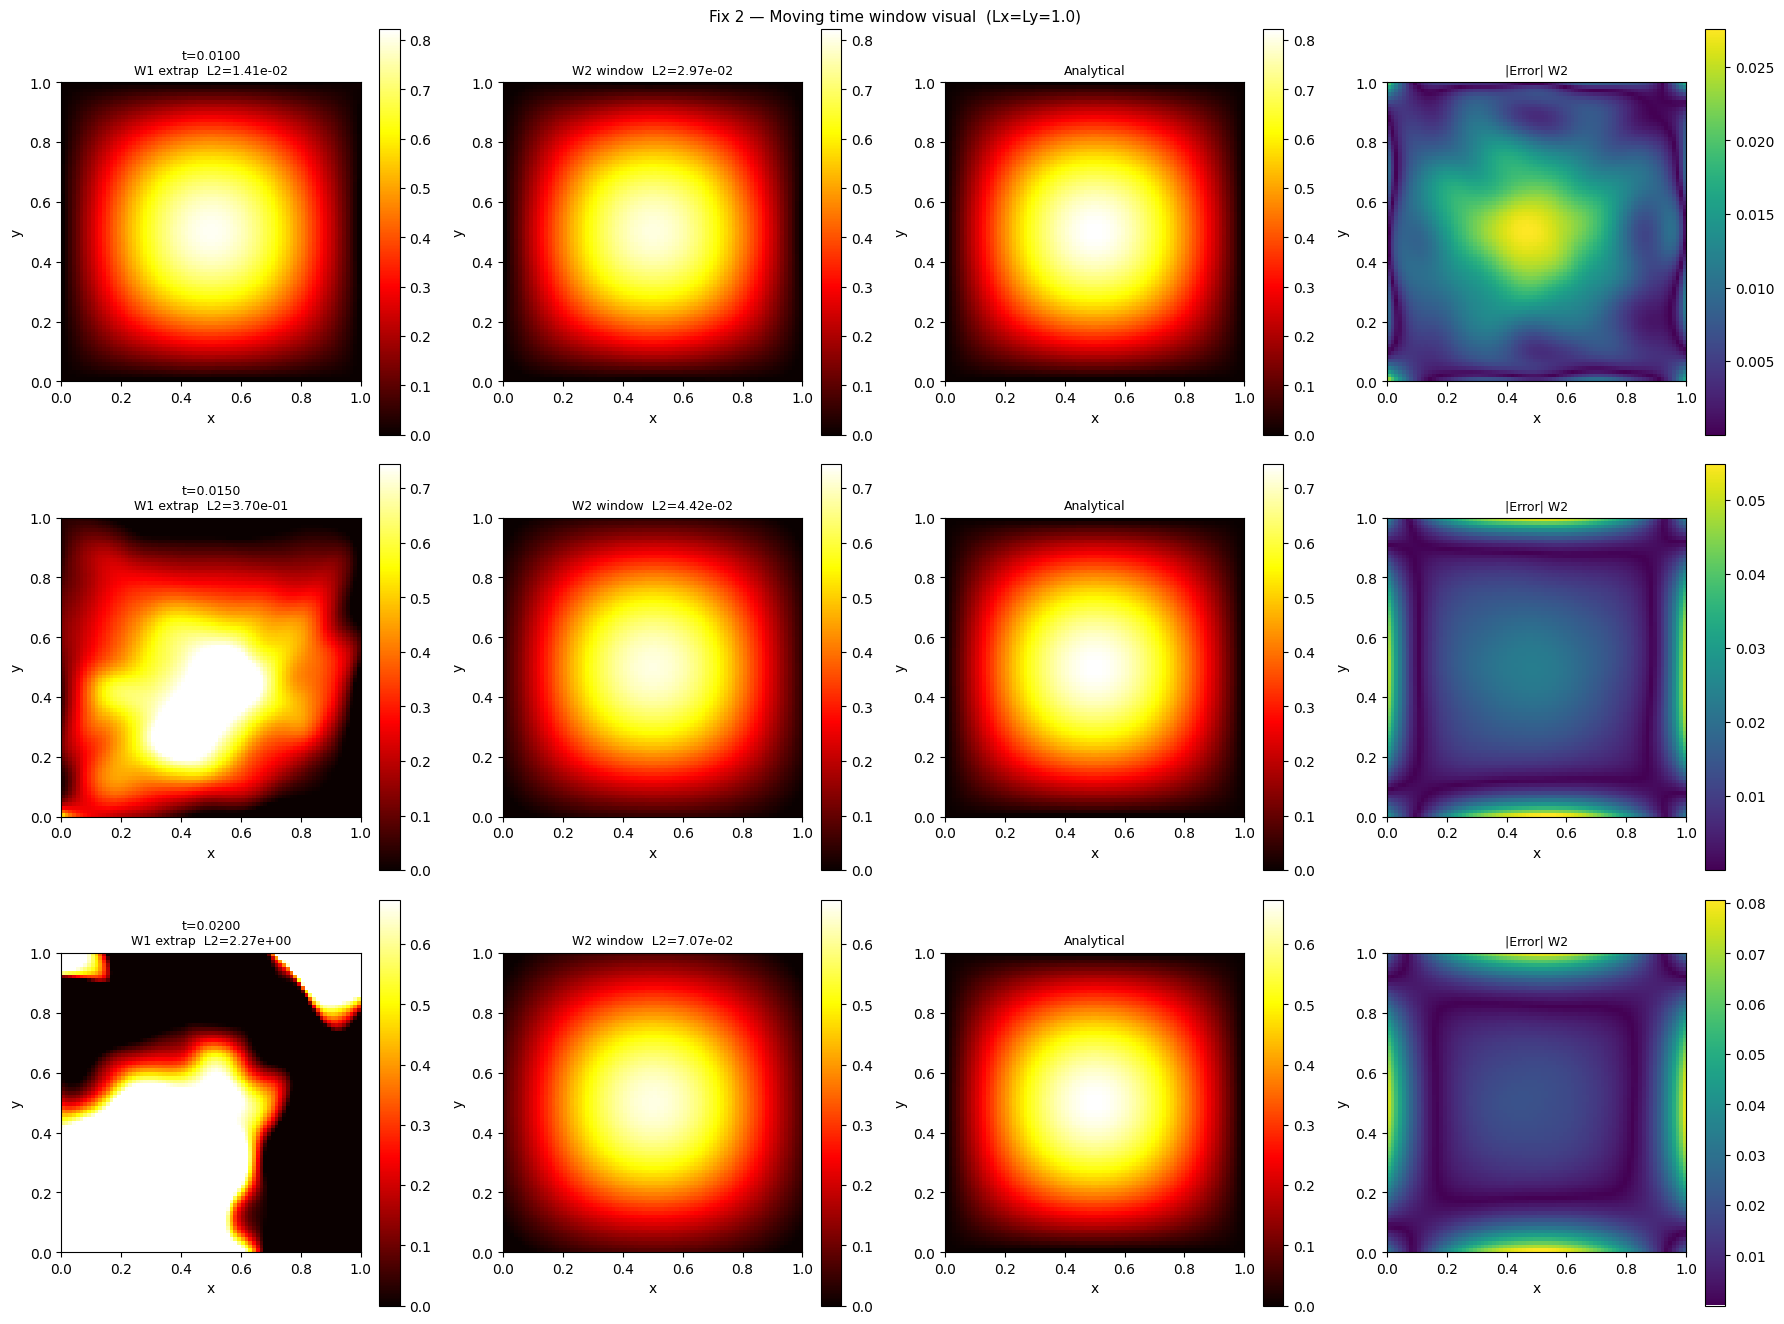

Saved fix2_time_window_visual.png


In [14]:
# Visual: snapshots at t=T_MAX, 1.5*T_MAX, 2*T_MAX
T_VIS = [T_MAX, 1.5*T_MAX, 2*T_MAX]

fig, axes = plt.subplots(len(T_VIS), 4, figsize=(18, 4.5*len(T_VIS)))
print(f'{"t":>7} | {"W1 L2":>9} | {"W2 L2":>9}')
for row, t_val in enumerate(T_VIS):
    l2_w1, T_w1, T_true = eval_l2(model,  Lx_t, Ly_t, t_val)
    l2_w2, T_w2, _      = eval_l2_w2(Lx_t, Ly_t, t_val)
    print(f'{t_val:>7.4f} | {l2_w1:>9.2e} | {l2_w2:>9.2e}')
    vmin=T_true.min(); vmax=T_true.max()
    kw=dict(origin='lower',extent=[0,Lx_t,0,Ly_t],cmap='hot',vmin=vmin,vmax=vmax)
    im=axes[row,0].imshow(T_w1,**kw)
    axes[row,0].set_title(f't={t_val:.4f}\nW1 extrap  L2={l2_w1:.2e}',fontsize=9); plt.colorbar(im,ax=axes[row,0])
    im=axes[row,1].imshow(T_w2,**kw)
    axes[row,1].set_title(f'W2 window  L2={l2_w2:.2e}',fontsize=9); plt.colorbar(im,ax=axes[row,1])
    im=axes[row,2].imshow(T_true,**kw)
    axes[row,2].set_title('Analytical',fontsize=9); plt.colorbar(im,ax=axes[row,2])
    im=axes[row,3].imshow(np.abs(T_w2-T_true),origin='lower',extent=[0,Lx_t,0,Ly_t],cmap='viridis')
    axes[row,3].set_title('|Error| W2',fontsize=9); plt.colorbar(im,ax=axes[row,3])
    for ax in axes[row]: ax.set_xlabel('x'); ax.set_ylabel('y')
fig.suptitle('Fix 2 — Moving time window visual  (Lx=Ly=1.0)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fix2_time_window_visual.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved fix2_time_window_visual.png')